In [1]:
!pip install openai numpy torch matplotlib logging torchvision

In [2]:
# Cell 1: Imports & Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import logging
from openai import OpenAI

# Configure logging
logging.basicConfig(filename="results.log",
                    level=logging.INFO,
                    format="%(asctime)s - %(message)s")

# Initialize OpenAI client
client = OpenAI()

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Cell 2: Load dataset (MNIST digits)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [4]:
# Cell 3: Define a simple CNN model
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

model = Net().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [5]:
# Cell 4: Training loop
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch} complete")

for epoch in range(1, 3):  # Train for 2 epochs
    train(model, device, train_loader, optimizer, epoch)

Epoch 1 complete
Epoch 2 complete


In [6]:
# Cell 5: Evaluate model
def test(model, device, test_loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    print(f"Test accuracy: {correct / len(test_loader.dataset):.4f}")

test(model, device, test_loader)

Test accuracy: 0.9885


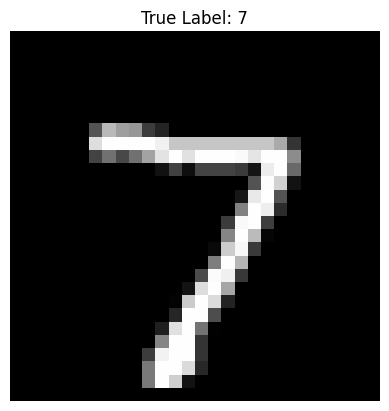

Predicted class: 7


In [7]:
# Cell 6: Predict a sample and visualize
sample_idx = 0
sample, label = test_dataset[sample_idx]
plt.imshow(sample.squeeze(), cmap="gray")
plt.title(f"True Label: {label}")
plt.axis("off")
plt.show()

sample = sample.unsqueeze(0).to(device)
output = model(sample)
predicted_class = output.argmax(dim=1).item()
print("Predicted class:", predicted_class)

In [8]:
# Cell 7: Explain prediction with OpenAI
response = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": f"The PyTorch CNN predicted '{predicted_class}' for a digit image. Explain how CNNs work for image classification in simple terms."}
    ]
)

explanation = response.choices[0].message.content
print("OpenAI Explanation:", explanation)

# Log results
logging.info(f"Prediction: {predicted_class}, Explanation: {explanation}")

OpenAI Explanation: Sure! Here’s a simple explanation of how CNNs (Convolutional Neural Networks) work for image classification, like recognizing the digit '7':

1. **Input Image**: The CNN starts with the image of the digit — in this case, a picture of a handwritten number.

2. **Convolution Layers**: The network looks at small parts of the image using filters (like tiny windows) that slide over the image. These filters help the CNN detect simple features such as edges, lines, or curves.

3. **Feature Extraction**: As the image passes through multiple convolution layers, the CNN combines the simple features it found earlier to recognize more complex patterns — like loops or angles that make up digits.

4. **Pooling Layers**: These layers make the image representation smaller and more manageable by summarizing small regions (like taking the maximum value). This helps the CNN focus on the most important features and reduces computational load.

5. **Fully Connected Layers**: After extra